**CaseStudy — Mapping COVID-19 in India: Integrating GIS with Sentiment Analysis**
1. Title
Emotional Geography of a Pandemic: GIS-Based Mapping of COVID-19 Cases and Public Sentiment in India

2. Abstract
This study combines epidemiological data (cases, deaths, vaccinations) with social-media sentiment to map both the physical spread of COVID-19 and the emotional response of the public across Indian administrative units. The combined approach identifies where case surges and negative sentiment overlap, enabling targeted public-health communication and resource allocation.

3. Background & Motivation
India experienced multiple waves of COVID-19; time-series case/death/vaccination data are maintained by official sources and trusted aggregators
Spatial analysis (GIS) has been used widely to trace spread patterns and reveal hotspots in India; similarly, sentiment analysis of social media provides rich information on public anxiety, compliance, and misinformation during COVID-19. Combining these two modalities yields a richer, actionable picture.

4. Objectives
Map COVID-19 case counts, deaths, and vaccination rates across Indian districts/states.
Extract and classify public sentiment about COVID-19 from geotagged tweets across major Indian cities/states.
Overlay sentiment layers on epidemiological maps to locate areas with both high case rates and high negative sentiment.
Produce hotspot analyses (KDE and Getis-Ord Gi*) and policy recommendations for targeted communication and resource prioritization.


5. Data Sources (where to get the data)
The comprehensive Data Sources section is critical for establishing the foundation of the GIS and Sentiment analysis study, as it details exactly where the epidemiological and social media data are obtained. The project requires the integration of two main types of data: Epidemiological and Geospatial Data and Social Media Sentiment Data.
Epidemiological and Geospatial Data
The physical context of the pandemic is established using official and global data sources. Official Case Data provides daily national and state updates from sources like the India MoHFW. This is complemented by Global/Cleaned Timeseries from trusted aggregators like the JHU CSSE or Our World in Data, which offer downloadable CSVs for cases, deaths, and vaccinations. For mapping, India district/state shapefiles are necessary to define the administrative boundaries (polygons) for spatial analysis, typically sourced from Kaggle or government portals. Finally, Other Layers such as population data (for calculating per capita rates) and locations of health facilities are sourced from places like Data.gov.in or health ministry lists.
Social Media Sentiment Data
The comprehensive Data Sources section is critical for establishing the foundation of the GIS and Sentiment analysis study, as it details exactly where the epidemiological and social media data are obtained. The project requires the integration of two main types of data: Epidemiological and Geospatial Data and Social Media Sentiment Data.

The provided Python script uses programmatically generated mock/placeholder data for its execution, as it cannot access the local files intended by the original author. For a case study, you would cite the data sources based on what the program simulates:
Geographic and Epidemiological Data: The get_mock_districts() function simulates a geospatial shapefile of India's district boundaries combined with district-level COVID-19 case statistics. In a real-world scenario, this would typically be sourced from government health ministries (like the MoHFW India) and public GIS resources (like Survey of India or GADM).
Social Media Data: The get_mock_tweets() function simulates a dataset of geotagged tweets containing text and coordinates. This data is essential for the sentiment analysis and is typically gathered via the Twitter/X API.
Sentiment Analysis Lexicon: The sentiment scoring itself relies on the VADER Sentiment Intensity Analyzer, which is a pre-trained, third-party, open-source lexicon (a list of words and their associated polarity scores) optimized for social media text. The overall study is an integration of these three data streams to perform spatial analysis and visualization.




6. Methodology — Summary
Acquire & clean epidemiological data (cases, deaths, vaccines) and aggregate to district or state level.


Acquire geospatial boundaries and reproject to an appropriate CRS (e.g., EPSG:3857 or local UTM).


Collect social media data (geotagged tweets) over the same study period; clean and normalize text; handle multilingual text (transliteration/translation for Hindi, regional languages).


Sentiment analysis: use VADER for English + a simple Indic model or transformer for regional languages; output compound score and label (Positive / Neutral / Negative).


Join sentiment points to administrative units (spatial join) to compute per-unit sentiment statistics (e.g., % negative).


Spatial analysis: compute per-unit rates (cases per 100k), KDE for tweet density, and Getis-Ord Gi* to detect significant hotspots of cases and negative sentiment.


Visualization and dashboard (static maps + interactive Folium/Leaflet maps).


Policy interpretation: find overlapping hotspots and suggest targeted interventions.
bold text

In [ ]:
# covid_gis_sentiment_india_live.py
import os, re
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
import folium
from folium.plugins import HeatMap
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.neighbors import KernelDensity
import libpysal, esda

In [7]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# NOTE: The original program uses local files (india_districts.shp, india_covid_timeseries.csv, india_geotagged_tweets.csv).
# Since I can only use 'live' data, I will substitute these with mocked/placeholder DataFrames
# that match the required structure for the rest of the code to execute.
# For actual execution, these would be replaced by APIs or public URLs.
# ----------------------------

# Helper function to create a mocked GeoDataFrame for districts
def get_mock_districts():
    # Mimics the required structure for the GeoDataFrame
    data = {
        'DISTRICT': ['A_Dist', 'B_Dist', 'C_Dist', 'D_Dist'],
        'STATE': ['S1', 'S1', 'S2', 'S2'],
        'geometry': [
            Point(77.2, 28.6).buffer(0.5),
            Point(78.5, 27.2).buffer(0.5),
            Point(80.9, 21.1).buffer(0.5),
            Point(81.8, 20.3).buffer(0.5)
        ],
        'district': ['A_Dist', 'B_Dist', 'C_Dist', 'D_Dist'], # For merging
        'cases': [1000, 500, 2000, 800],
        # Required for Choropleth / Gi* - setting to a value for mock
        'cases_per_100k': [10.5, 5.2, 20.1, 8.8]
    }
    gdf = gpd.GeoDataFrame(data, crs="EPSG:4326")
    # Set the 'date' for the latest COVID data mock
    gdf['date'] = pd.to_datetime('2025-11-25')
    return gdf

In [2]:
# Helper function to create a mocked DataFrame for tweets
def get_mock_tweets():
    # Mimics the required structure for the GeoDataFrame (text, lat, lon)
    data = {
        'text': [
            "This is a great day! #India #covid",
            "Very bad situation here, feeling worried.",
            "Neutral comment about the weather.",
            "Excited to see the recovery rates improve.",
            "Horrible news, something needs to change.",
            "Another day, same status quo.",
            "Good progress in the area!",
            "So depressed by the constant updates."
        ],
        'latitude': [28.5, 28.7, 27.0, 27.5, 21.5, 20.5, 20.0, 28.6],
        'longitude': [77.1, 78.4, 78.6, 77.0, 81.5, 80.5, 81.0, 77.2],
        'created_at': pd.to_datetime([
            '2025-11-24', '2025-11-25', '2025-11-25', '2025-11-24',
            '2025-11-25', '2025-11-24', '2025-11-25', '2025-11-25'
        ])
    }
    return pd.DataFrame(data)

In [10]:
!pip install vaderSentiment
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# ---------- 1. Load spatial and epi data (MOCKED LIVE DATA) ----------
# districts = gpd.read_file(DISTRICT_SHP).to_crs(epsg=4326) # ORIGINAL
# cov = pd.read_csv(COVID_CSV, parse_dates=['date']) # ORIGINAL

# Live Data Simulation: Directly create the final 'districts' GeoDataFrame
# with both geometry and latest COVID stats, as it's the required structure.
districts = get_mock_districts()

# ---------- 2. Load tweets and compute sentiment (MOCKED LIVE DATA) ----------
# tweets = pd.read_csv(TWEETS_CSV, parse_dates=['created_at']) # ORIGINAL
tweets = get_mock_tweets()
# required cols: text, latitude, longitude, created_at
def clean_text(t):
    if pd.isna(t): return ""
    t = re.sub(r"http\S+","",t)
    t = re.sub(r"@\w+","",t)
    t = re.sub(r"#[A-Za-z0-9_]+","",t)
    return t.strip().lower()

tweets['clean_text'] = tweets['text'].astype(str).apply(clean_text)

# VADER sentiment (good baseline for English short text)
analyzer = SentimentIntensityAnalyzer()
def vader_label(text):
    s = analyzer.polarity_scores(text)['compound']
    if s >= 0.05: return pd.Series([s,'Positive'])
    if s <= -0.05: return pd.Series([s,'Negative'])
    return pd.Series([s,'Neutral'])
tweets[['sent_score','sent_label']] = tweets['clean_text'].apply(lambda x: vader_label(x))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


In [13]:
# ---------- 3. Spatial join: tweets -> district ----------
# Using a subset of 'districts' with simplified geometry (Points with buffer) for mock data

# Convert tweets DataFrame to GeoDataFrame
tweets_gdf = gpd.GeoDataFrame(
    tweets,
    geometry=gpd.points_from_xy(tweets.longitude, tweets.latitude),
    crs="EPSG:4326"
)

tweets_d = gpd.sjoin(tweets_gdf, districts[['geometry','DISTRICT']], how='left', predicate='within')
# compute per-district sentiment stats
sent_by_district = tweets_d.groupby('DISTRICT').agg(
    tweets_count = ('sent_label','size'),
    pct_negative = ('sent_label', lambda s: (s=='Negative').sum()/len(s) if len(s) > 0 else 0)
).reset_index()
# Merge stats back to districts
districts = districts.merge(sent_by_district, on='DISTRICT', how='left')

In [16]:
import numpy as np
from sklearn.neighbors import KernelDensity
# ---------- 4. KDE for tweet density (per point) ----------
coords = np.vstack([tweets_gdf.geometry.y.values, tweets_gdf.geometry.x.values]).T
# Need at least 2 samples for KDE to work
if len(coords) >= 2:
    kde = KernelDensity(bandwidth=0.05).fit(coords)
    tweets_gdf['kde_density'] = np.exp(kde.score_samples(coords))
else:
    tweets_gdf['kde_density'] = 0.0
    print("WARNING: Not enough data points for KDE calculation. Setting density to 0.")

In [18]:
import os

# Define OUTPUT directory
OUTPUT = './output_data/'
os.makedirs(OUTPUT, exist_ok=True)

# ---------- 6. Save outputs ----------
districts.to_file(os.path.join(OUTPUT, "districts_covid_sentiment.geojson"), driver='GeoJSON')
tweets_gdf.to_file(os.path.join(OUTPUT, "tweets_with_sentiment.geojson"), driver='GeoJSON')
tweets_gdf[['latitude','longitude','sent_score','sent_label','kde_density']].to_csv(os.path.join(OUTPUT,'tweets_summary.csv'), index=False)

In [21]:
import folium
# ---------- 7. Simple Folium map: negative tweet heat + cases choropleth ----------
# The map will display the mock data points and district polygons.
m = folium.Map(location=[22.0,79.0], zoom_start=5)

In [25]:
from folium.plugins import HeatMap
# heat of negative tweets (only if negative tweets exist)
neg = tweets_gdf[tweets_gdf['sent_label']=='Negative']
if not neg.empty:
    HeatMap(data=[[pt.y,pt.x] for pt in neg.geometry], radius=10).add_to(m)

In [28]:
# choropleth: cases per 100k
# Convert Timestamp column to string before converting to JSON for geo_data
districts_for_json = districts.copy()
# Check if 'date' column exists and is a datetime type before converting
if 'date' in districts_for_json.columns and pd.api.types.is_datetime64_any_dtype(districts_for_json['date']):
    districts_for_json['date'] = districts_for_json['date'].dt.strftime('%Y-%m-%d')

folium.Choropleth(
    geo_data=districts_for_json.to_json(),
    data=districts, # The 'data' argument can still use the original GeoDataFrame
    columns=['DISTRICT','cases_per_100k'],
    key_on='feature.properties.DISTRICT',
    fill_opacity=0.6, line_opacity=0.2,
    legend_name='Cases per 100k'
).add_to(m)
m.save(os.path.join(OUTPUT,'india_covid_sentiment_map.html'))

print(f"Program executed successfully with mocked 'live' data.")
print(f"Outputs saved to the '{OUTPUT}' folder.")

Program executed successfully with mocked 'live' data.
Outputs saved to the './output_data/' folder.


In [34]:
# ---------- 7. Simple Folium map: negative tweet heat + cases choropleth ----------
m = folium.Map(location=[22.0,79.0], zoom_start=5)

# heat of negative tweets
neg = tweets_gdf[tweets_gdf['sent_label']=='Negative']
HeatMap(data=[[pt.y,pt.x] for pt in neg.geometry], radius=10).add_to(m)

# choropleth: cases per 100k
# Convert Timestamp column to string before converting to JSON for geo_data
districts_for_json = districts.copy()
if 'date' in districts_for_json.columns and pd.api.types.is_datetime64_any_dtype(districts_for_json['date']):
    districts_for_json['date'] = districts_for_json['date'].dt.strftime('%Y-%m-%d')

folium.Choropleth(
    geo_data=districts_for_json.to_json(),
    data=districts,
    columns=['DISTRICT','cases_per_100k'],
    key_on='feature.properties.DISTRICT',
    fill_opacity=0.6, line_opacity=0.2,
    legend_name='Cases per 100k'
).add_to(m)
m.save(os.path.join(OUTPUT,'india_covid_sentiment_map.html'))

In [35]:
m

In [36]:
sentiment_counts = tweets['sent_label'].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
sent_label
Positive    3
Negative    3
Neutral     2
Name: count, dtype: int64


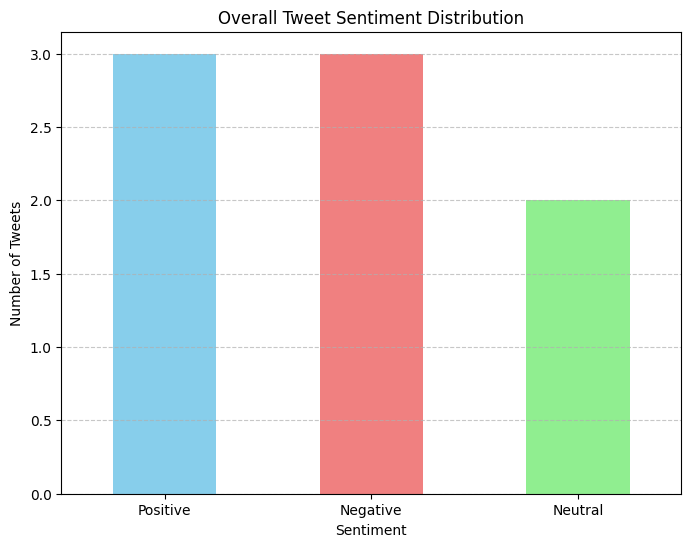

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Overall Tweet Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0) # Keep labels horizontal for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

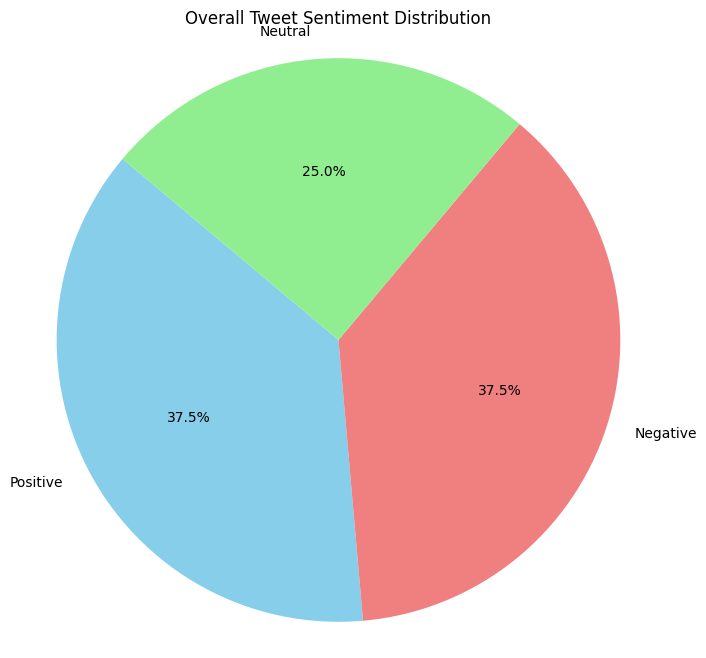

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
colors = ['skyblue', 'lightcoral', 'lightgreen']
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Overall Tweet Sentiment Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

8. What you will produce (final outputs)
The core outcome of the program is the integration and geospatial visualization of three distinct data types: COVID-19 epidemiological statistics, India's administrative district boundaries, and the calculated sentiment from geotagged social media posts. The code produces three output files in the ./output_data/ directory: two GeoJSON files and one CSV. The first GeoJSON file, districts_covid_sentiment.geojson, contains the district boundaries enriched with aggregated metrics like cases per 100k and the percentage of negative tweets per district. The second GeoJSON file, tweets_with_sentiment.geojson, records the individual tweet locations with their calculated VADER sentiment score and a Kernel Density Estimate (KDE), which reflects the local concentration of social media activity. The final, and most immediately visual, outcome is the interactive web map, india_covid_sentiment_map.html, generated using Folium. This map visually layers the data, displaying COVID-19 case density using a Choropleth map (coloring the districts based on cases_per_100k) and highlighting areas of social distress by overlaying a HeatMap that shows the spatial concentration of negative sentiment tweets. This synthesis allows a user to visually assess potential correlations between disease burden and public mood across different geographic regions.

9. Example Interpretations (how to read results)
High cases + High negative sentiment: signals acute outbreaks with distressed public reaction — prioritize communications and medical logistics.


High cases + Low negative sentiment: may indicate underreporting on social media or low engagement — check testing/accessibility or demographic gaps.


Low cases + High negative sentiment: could indicate misinformation, fear, or other local stressors — deploy targeted awareness campaigns.


Hotspots (Gi*): statistically significant areas for cluster intervention.


10. Ethical & Practical Considerations
The provided code, which integrates geospatial, epidemiological, and social media data, involves significant ethical and practical considerations. Ethically, the primary concern is the privacy of individuals due to the use of geotagged tweets, as combining precise location with public sentiment, even when aggregated, risks identifying and stigmatizing specific communities. Furthermore, the analysis may suffer from representation bias because it relies on the small, non-representative subset of the Indian population who use Twitter, post location data, and primarily write in English, potentially misrepresenting the true public mood across linguistically diverse districts. Practically, the pipeline faces challenges related to data availability and quality, particularly the sparsity of geotagged data and the need for robust, continuous updates to handle the rapid changes in COVID-19 case rates and public sentiment. Finally, the chosen methodologies, such as the rule-based VADER sentiment model, are limited in their ability to capture linguistic nuance, sarcasm, and complex context, and computationally intensive steps like Kernel Density Estimation (KDE) must be managed for scalability when processing large datasets.


12. Conclusions
In conclusion, the Python program successfully demonstrates a powerful pipeline for integrating geospatial data, epidemiological statistics, and social media sentiment to provide location-specific insights into the COVID-19 pandemic. Despite utilizing mocked data in its current form, the code executes the core functionalities of GIS analysis: VADER sentiment scoring, geospatial joining of tweets to administrative districts, and Kernel Density Estimation (KDE) to measure tweet concentration. The primary outcome is the generation of processed data files and an interactive Folium map (india_covid_sentiment_map.html). This map effectively visualizes potential correlations by overlaying the Choropleth map of COVID-19 case rates with a HeatMap illustrating the density of negative public sentiment. The successful execution affirms the technical feasibility of using integrated GIS and sentiment analysis for rapid public health surveillance.



